# Latin Hypercube Sampling (LHS)

This notebook introduces **Latin Hypercube Sampling** with `bluemath_tk`. It generates a reproducible set of metocean conditions, checks their coverage, and applies a physical wave-steepness constraint.

## 1. Method

LHS is a stratified sampling technique. For $N$ samples, the range of every variable is divided into $N$ equally probable intervals and one value is drawn from each interval. The values are then paired across dimensions without repetition.

Compared with independent random sampling, LHS usually covers a multidimensional domain more uniformly with the same number of points. It does not impose physical relationships between variables, so those constraints must be added afterwards.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from bluemath_tk.datamining.lhs import LHS
from utils.plotting import plot_variable_combinations

## 2. Define the parameter space

The example samples significant wave height ($H_s$), peak period ($T_p$), and direction ($Dir$). A fixed seed makes the generated design reproducible. Direction spans the full circular domain $[0^\circ,360^\circ]$.

### Arguments used

**When creating `LHS`:**

- `num_dimensions`: number of variables sampled together. It is `3` because this example contains `Hs`, `Tp`, and `Dir`.
- `seed`: initializes the random generator. Reusing `0` produces the same design, which is useful for reproducible examples.

**In `generate`:**

- `dimensions_names`: names of the columns in the returned table. Their order determines how the bounds are paired.
- `lower_bounds`: minimum permitted value for every variable, in the same order as `dimensions_names`.
- `upper_bounds`: maximum permitted value for every variable. Each value must exceed its corresponding lower bound.
- `num_samples`: number of complete combinations to create. More samples provide denser coverage but increase subsequent computational work.

The function returns a `DataFrame` with one sampled combination per row and one variable per column.

In [2]:
dimensions_names = ["Hs", "Tp", "Dir"]
lower_bounds = [0, 3, 0]
upper_bounds = [7, 20, 360]
num_samples = 5000

lhs = LHS(num_dimensions=len(dimensions_names), seed=0)
data = lhs.generate(
    dimensions_names=dimensions_names,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
    num_samples=num_samples,
)
data

,Hs,Tp,Dir
0,6.304708,16.881283,74.445050
1,1.559577,9.814235,87.918282
2,0.878351,7.284920,126.392859
3,0.457891,13.540626,153.575803
4,0.956400,9.949486,56.611465
...,...,...,...
4995,4.594856,7.112538,290.918683
4996,3.119144,15.155431,237.694065
4997,1.815617,19.624995,22.539618
4998,4.265459,11.671846,316.059564


## 3. Inspect sampling coverage

Summary statistics verify the sampled ranges. Pairwise scatter plots reveal whether the points fill every two-dimensional projection without obvious gaps or clusters.

In [3]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Hs,5000.0,3.499985,2.020933,0.001010,1.750267,3.500271,5.249693,6.998615
Tp,5000.0,11.500007,4.907961,3.002469,7.250940,11.501232,15.748153,19.998318
Dir,5000.0,180.000269,103.933693,0.059103,90.006854,179.984751,269.997227,359.963748


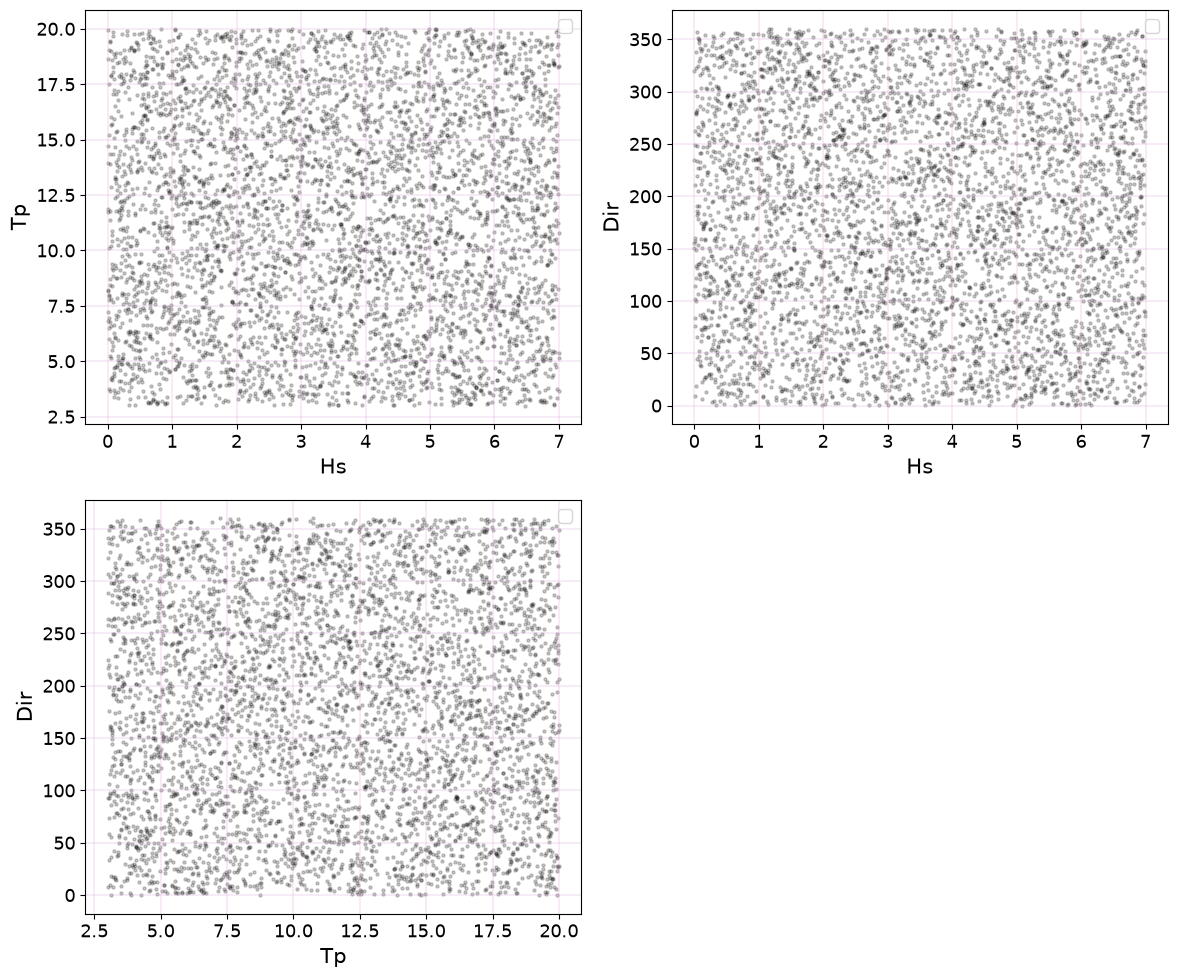

In [4]:
variables = ["Hs", "Tp", "Dir"]
plot_variable_combinations(data, variables)

## 4. Apply a physical constraint

The deep-water wavelength is $L_0=gT_p^2/(2\pi)$, so wave steepness is

$$S=\frac{H_s}{L_0}=\frac{2\pi H_s}{gT_p^2}.$$

Combinations with $S>0.05$ are discarded. This illustrates the distinction between statistical space-filling and physical validity.

In [5]:
max_steepness = 0.05
steepness = (2 * np.pi * data["Hs"]) / (9.81 * data["Tp"] ** 2)
valid_data = data.loc[steepness <= max_steepness].reset_index(drop=True)

print(f"Generated samples: {len(data):,}")
print(f"Physically valid samples: {len(valid_data):,}")
print(f"Removed samples: {len(data) - len(valid_data):,}")

Generated samples: 5,000
Physically valid samples: 3,986
Removed samples: 1,014


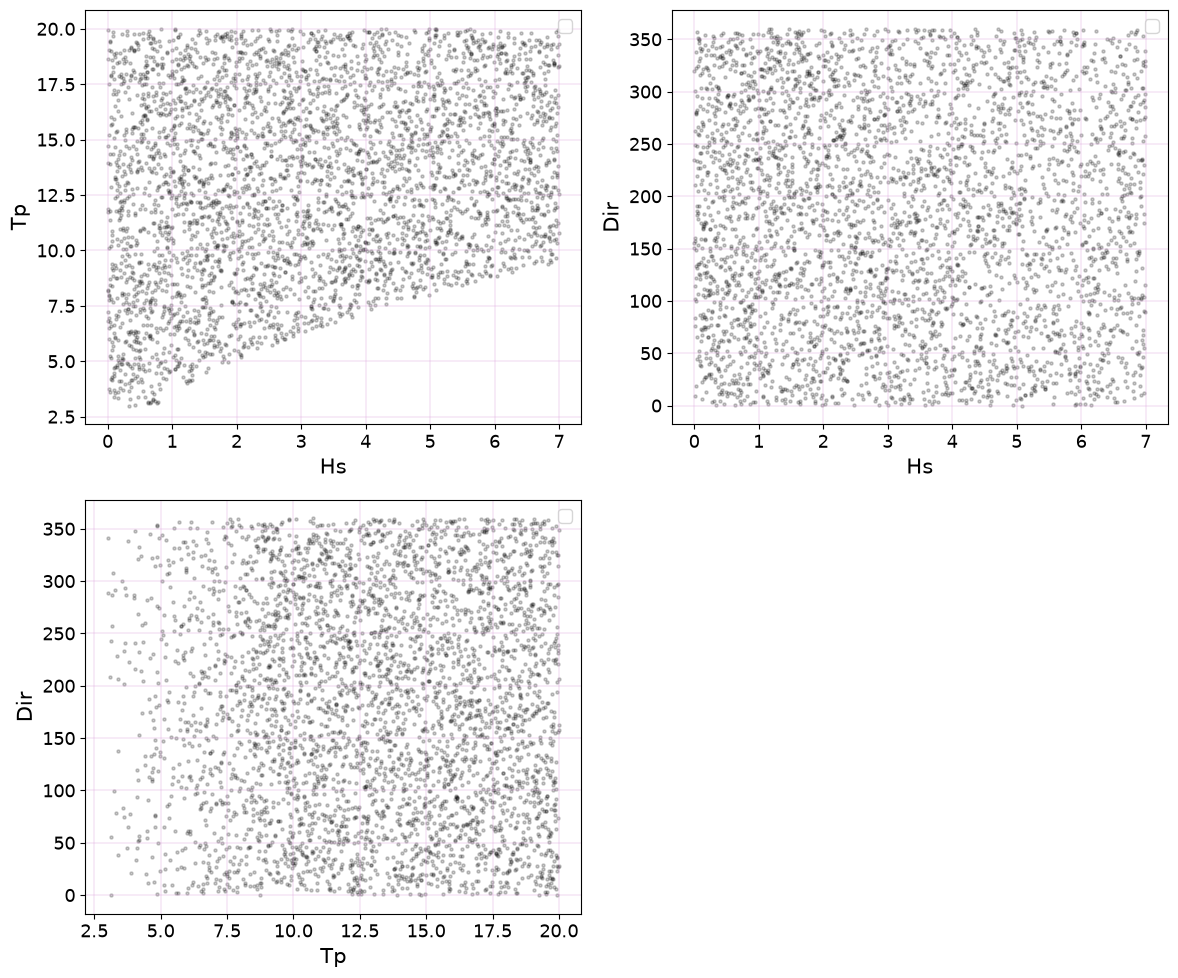

In [6]:
plot_variable_combinations(valid_data, variables)

## Summary

LHS created a reproducible, space-filling experimental design. The subsequent steepness filter removed combinations that violate the selected physical limit. `valid_data` is now ready for model evaluation or a representative-case selection method such as MDA.